# H-CAST Output Analysis

This notebook analyzes training/test artifacts in `/scratch/g.saggini1/outputs/` and compares:

- baseline `/scratch/g.saggini1/outputs/hcast_cifar100`
- temperature variants from runs matching `/scratch/g.saggini1/outputs/hcast_hcc_cifar100*`

It includes:
- validation curves for `fpa_topdown` and `weighted_ap_topdown`,
- per-level validation top-down accuracy curves,
- a final test comparison table with deltas,
- projection diagnostics (`proj_constraint_alpha`, `proj_constraint_strength`, `proj_temperature`, etc.),
- short interpretation snippets after each analysis block.


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import yaml
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def resolve_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / 'configs').exists():
            return candidate
    return cwd


PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [2]:
_ACC_LEVEL_PATTERN = re.compile(r'^acc_level_(\\d+)$')
_ACC_LEVEL_TOPDOWN_PATTERN = re.compile(r'^acc_level_topdown_(\\d+)$')
_ACC_LEVEL_INDEPENDENT_PATTERN = re.compile(r'^acc_level_independent_(\\d+)$')


def _as_float_dict(metrics):
    out = {}
    if not isinstance(metrics, dict):
        return out
    for key, value in metrics.items():
        try:
            out[str(key)] = float(value)
        except (TypeError, ValueError):
            continue
    return out


def normalize_metrics(metrics):
    """Normalize metric key variants from older/newer logs into one schema."""
    out = _as_float_dict(metrics)

    # Weighted AP aliases
    if 'weighted_ap_topdown' not in out:
        if 'weighted_ap' in out:
            out['weighted_ap_topdown'] = out['weighted_ap']
        elif 'weighted_ap_independent' in out:
            out['weighted_ap_topdown'] = out['weighted_ap_independent']
    if 'weighted_ap_independent' not in out and 'weighted_ap_topdown' in out:
        out['weighted_ap_independent'] = out['weighted_ap_topdown']

    # FPA aliases
    if 'fpa_topdown' not in out:
        if 'fpa' in out:
            out['fpa_topdown'] = out['fpa']
        elif 'fpa_independent' in out:
            out['fpa_topdown'] = out['fpa_independent']
    if 'fpa_independent' not in out and 'fpa_topdown' in out:
        out['fpa_independent'] = out['fpa_topdown']

    # TICE aliases
    if 'tice_topdown' not in out:
        if 'tice' in out:
            out['tice_topdown'] = out['tice']
        elif 'tice_independent' in out:
            out['tice_topdown'] = out['tice_independent']
    if 'tice_independent' not in out and 'tice_topdown' in out:
        out['tice_independent'] = out['tice_topdown']

    # AHD aliases
    if 'ahd_topdown' not in out:
        if 'ahd' in out:
            out['ahd_topdown'] = out['ahd']
        elif 'ahd_independent' in out:
            out['ahd_topdown'] = out['ahd_independent']
    if 'ahd_independent' not in out and 'ahd_topdown' in out:
        out['ahd_independent'] = out['ahd_topdown']

    # Legacy per-level accuracy aliases (acc_level_{i})
    for key, value in list(out.items()):
        match = _ACC_LEVEL_PATTERN.match(key)
        if match:
            level_idx = int(match.group(1))
            out.setdefault(f'acc_level_independent_{level_idx}', value)
            out.setdefault(f'acc_level_topdown_{level_idx}', value)

    # Fill missing top-down/independent level metrics from each other when only one exists.
    level_ids = set()
    for key in list(out.keys()):
        match = _ACC_LEVEL_TOPDOWN_PATTERN.match(key)
        if match:
            level_ids.add(int(match.group(1)))
            continue
        match = _ACC_LEVEL_INDEPENDENT_PATTERN.match(key)
        if match:
            level_ids.add(int(match.group(1)))

    for level_idx in level_ids:
        topdown_key = f'acc_level_topdown_{level_idx}'
        independent_key = f'acc_level_independent_{level_idx}'
        if topdown_key not in out and independent_key in out:
            out[topdown_key] = out[independent_key]
        if independent_key not in out and topdown_key in out:
            out[independent_key] = out[topdown_key]

    return out


def load_jsonl_events(path):
    events = []
    with Path(path).open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                events.append(json.loads(line))
    return events


def load_yaml(path):
    with Path(path).open('r', encoding='utf-8') as f:
        return yaml.safe_load(f)


def metric_for_best(metrics):
    """Mirror train.utils.metric_for_best for consistent best-epoch selection."""
    m = normalize_metrics(metrics)

    has_fpa = 'fpa_topdown' in m
    has_tice = 'tice_topdown' in m
    has_wap = 'weighted_ap_topdown' in m

    if has_fpa or has_tice or has_wap:
        fpa = float(m.get('fpa_topdown', 0.0))
        neg_tice = -float(m.get('tice_topdown', 1.0))
        wap = float(m.get('weighted_ap_topdown', 0.0))
        return float(fpa + 1e-3 * neg_tice + 1e-6 * wap)

    topdown_keys = [
        key
        for key in m
        if key.startswith('acc_level_topdown_') and key.rsplit('_', 1)[-1].isdigit()
    ]
    independent_keys = [
        key
        for key in m
        if key.startswith('acc_level_independent_') and key.rsplit('_', 1)[-1].isdigit()
    ]
    deepest = topdown_keys or independent_keys
    if not deepest:
        return float(m.get('fpa_topdown', 0.0))

    deepest_key = max(deepest, key=lambda key: int(key.rsplit('_', 1)[-1]))
    primary = float(m.get(deepest_key, 0.0))
    tie = float(m.get('fpa_topdown', 0.0))
    return float(primary + 1e-3 * tie)


def parse_run(run_dir):
    run_path = Path(run_dir)
    events = load_jsonl_events(run_path / 'run_log.jsonl')
    epoch_events = [event for event in events if event.get('event') == 'epoch']

    for event in epoch_events:
        event['train_metrics_norm'] = normalize_metrics(event.get('train_metrics', {}))
        event['val_metrics_norm'] = normalize_metrics(event.get('val_metrics', {}))
        event['rank_score'] = metric_for_best(event['val_metrics_norm'])

    test_events = [event for event in events if event.get('event') == 'test']
    test_event = test_events[-1] if test_events else {}
    test_metrics = normalize_metrics(test_event.get('test_metrics', {}))

    test_metrics_yaml = {}
    test_yaml_path = run_path / 'test_metrics.yaml'
    if test_yaml_path.exists():
        test_metrics_yaml = load_yaml(test_yaml_path) or {}
        if not test_metrics:
            test_metrics = normalize_metrics(test_metrics_yaml.get('test_metrics', {}))

    level_names = []
    cfg_path = run_path / 'config_resolved.yaml'
    if cfg_path.exists():
        cfg = load_yaml(cfg_path) or {}
        level_names = list(cfg.get('dataset', {}).get('levels', []))

    best_epoch_event = None
    if epoch_events:
        best_idx = int(np.argmax([event['rank_score'] for event in epoch_events]))
        best_epoch_event = epoch_events[best_idx]

    return {
        'run_dir': run_path,
        'events': events,
        'epoch_events': epoch_events,
        'test_event': test_event,
        'test_metrics': test_metrics,
        'test_metrics_yaml': test_metrics_yaml,
        'level_names': level_names,
        'best_epoch_event': best_epoch_event,
    }


def get_metric_series(epoch_events, metric_key):
    epochs = [int(event['epoch']) for event in epoch_events]
    values = [float(event['val_metrics_norm'].get(metric_key, np.nan)) for event in epoch_events]
    return np.array(epochs, dtype=np.int32), np.array(values, dtype=np.float64)


def get_level_label(level_idx, run_data):
    names = run_data.get('level_names') or []
    if level_idx < len(names):
        return str(names[level_idx])
    return f'L{level_idx}'


In [3]:
from collections import Counter

INCLUDE_BASELINE = True
BASELINE_RUN_DIR = OUTPUTS_ROOT / 'hcast_cifar100'
BASELINE_LABEL = 'H-CAST'
BASELINE_COLOR = '#1f77b4'

# Optional manual override. If empty, runs are auto-discovered with glob.
# Relative paths are resolved from OUTPUTS_ROOT.
MANUAL_TEMPERATURE_RUN_DIRS = []
AUTO_DISCOVER_PATTERN = 'hcast_hcc_cifar100*'

TEMPERATURE_COLOR_PALETTE = [
    '#d62728', '#2ca02c', '#ff7f0e', '#9467bd',
    '#8c564b', '#17becf', '#e377c2', '#bcbd22',
]


def _resolve_run_dir(path_like):
    path = Path(path_like)
    if path.is_absolute():
        return path
    return OUTPUTS_ROOT / path


def _read_hcc_cfg(run_dir):
    cfg_path = Path(run_dir) / 'config_resolved.yaml'
    if not cfg_path.exists():
        return {}
    cfg = load_yaml(cfg_path) or {}
    hcc_cfg = cfg.get('model', {}).get('hcc', {})
    if not isinstance(hcc_cfg, dict):
        return {}
    return dict(hcc_cfg)


def _read_hcc_temperature(run_dir):
    hcc_cfg = _read_hcc_cfg(run_dir)
    raw_temp = hcc_cfg.get('temperature', None)
    if raw_temp is None:
        return None
    try:
        return float(raw_temp)
    except (TypeError, ValueError):
        return None


def _read_hcc_projection_mode(run_dir):
    hcc_cfg = _read_hcc_cfg(run_dir)
    mode = hcc_cfg.get('projection_mode', None)
    if mode is None:
        return None
    return str(mode)


def _read_hcc_constraint_strength_max(run_dir):
    hcc_cfg = _read_hcc_cfg(run_dir)
    raw = hcc_cfg.get('constraint_strength_max', None)
    if raw is None:
        return None
    try:
        value = float(raw)
    except (TypeError, ValueError):
        return None
    return min(max(value, 0.0), 1.0)


if MANUAL_TEMPERATURE_RUN_DIRS:
    candidate_dirs = [_resolve_run_dir(path_like) for path_like in MANUAL_TEMPERATURE_RUN_DIRS]
else:
    candidate_dirs = sorted(OUTPUTS_ROOT.glob(AUTO_DISCOVER_PATTERN))

temperature_runs_meta = []
for run_dir in candidate_dirs:
    run_dir = Path(run_dir)
    if not run_dir.exists() or not run_dir.is_dir():
        continue
    if not (run_dir / 'run_log.jsonl').exists():
        continue
    temperature = _read_hcc_temperature(run_dir)
    if temperature is None:
        continue
    temperature_runs_meta.append((
        temperature,
        run_dir,
        _read_hcc_projection_mode(run_dir),
        _read_hcc_constraint_strength_max(run_dir),
    ))

temperature_runs_meta.sort(key=lambda item: (item[0], item[1].name))
temp_counts = Counter(temp for temp, _, _, _ in temperature_runs_meta)

RUNS = []
if INCLUDE_BASELINE and (BASELINE_RUN_DIR / 'run_log.jsonl').exists():
    RUNS.append({
        'label': BASELINE_LABEL,
        'run_dir': BASELINE_RUN_DIR,
        'color': BASELINE_COLOR,
        'temperature': None,
        'hcc_projection_mode': None,
        'hcc_constraint_strength_max': None,
    })

for idx, (temperature, run_dir, projection_mode, constraint_strength_max) in enumerate(temperature_runs_meta):
    label = f'H-CAST HCC T={temperature:g}'
    if temp_counts[temperature] > 1:
        label = f"{label} ({run_dir.name})"
    RUNS.append({
        'label': label,
        'run_dir': run_dir,
        'color': TEMPERATURE_COLOR_PALETTE[idx % len(TEMPERATURE_COLOR_PALETTE)],
        'temperature': float(temperature),
        'hcc_projection_mode': projection_mode,
        'hcc_constraint_strength_max': constraint_strength_max,
    })

if not RUNS:
    raise ValueError('No runs found. Check output paths or MANUAL_TEMPERATURE_RUN_DIRS.')

run_data_list = []
for run in RUNS:
    parsed = parse_run(run['run_dir'])
    parsed.update(run)
    run_data_list.append(parsed)

for run_data in run_data_list:
    epoch_count = len(run_data['epoch_events'])
    best_epoch = run_data['best_epoch_event']['epoch'] if run_data['best_epoch_event'] else None
    best_score = run_data['best_epoch_event']['rank_score'] if run_data['best_epoch_event'] else None
    temperature = run_data.get('temperature', None)
    projection_mode = run_data.get('hcc_projection_mode', None)
    strength_max = run_data.get('hcc_constraint_strength_max', None)

    temp_txt = '' if temperature is None else f', T={temperature:g}'
    mode_txt = '' if projection_mode is None else f', proj_mode={projection_mode}'
    if strength_max is None or not np.isfinite(strength_max):
        strength_txt = ''
    else:
        strength_txt = f', strength_max={strength_max:g}'

    print(
        f"{run_data['label']}: epochs={epoch_count}, best_epoch={best_epoch}, "
        f"best_score={best_score}{temp_txt}{mode_txt}{strength_txt}"
    )


H-CAST: epochs=100, best_epoch=96, best_score=0.7497078064483643
H-CAST HCC T=1: epochs=100, best_epoch=100, best_score=0.5829107968292236, T=1
H-CAST HCC T=5: epochs=100, best_epoch=90, best_score=0.7453132709594728, T=5
H-CAST HCC T=10 (hcast_hcc_cifar100_temp10): epochs=100, best_epoch=100, best_score=0.741114048248291, T=10
H-CAST HCC T=10 (hcast_hcc_cifar100_temp10_soft): epochs=100, best_epoch=90, best_score=0.7459968651947021, T=10
H-CAST HCC T=10 (hcast_hcc_cifar100_temp10_withoutgk): epochs=100, best_epoch=90, best_score=0.744532020437622, T=10


## H-CAST Variants (CIFAR-100): Validation Curves

Each panel overlays both decoding modes on the **same axes**:

- color = run (baseline + temperature variants)
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, and `TICE`.


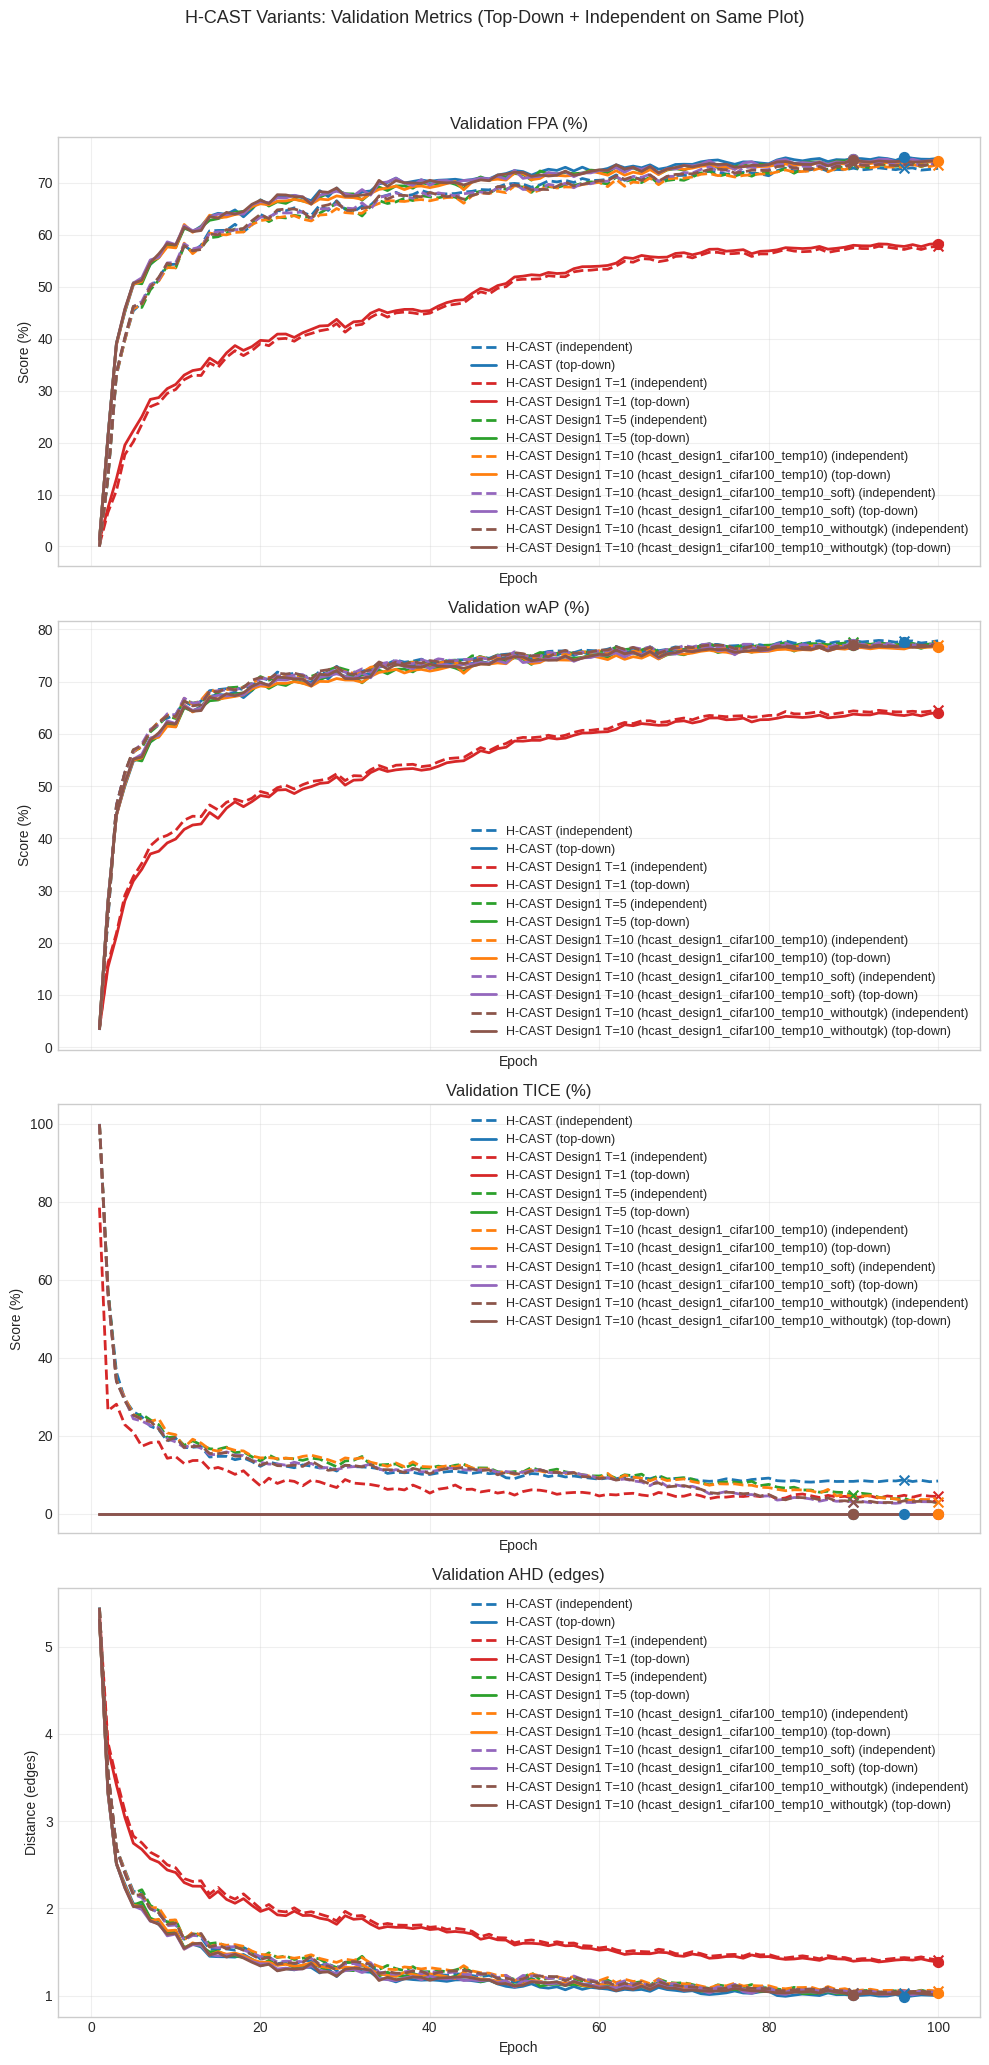

In [4]:
metric_families = [
    ('fpa', 'Validation FPA (%)', True),
    ('weighted_ap', 'Validation wAP (%)', True),
    ('tice', 'Validation TICE (%)', True),
    ('ahd', 'Validation AHD (edges)', False),
]
mode_specs = [
    ('independent', '--', 'independent', 'x'),
    ('topdown', '-', 'top-down', 'o'),
]

fig, axes = plt.subplots(len(metric_families), 1, figsize=(10, 5 * len(metric_families)), sharex=True)
if len(metric_families) == 1:
    axes = [axes]

for ax, (metric_prefix, metric_title, is_percent) in zip(axes, metric_families):
    for run_data in run_data_list:
        for mode_key, line_style, mode_label, marker in mode_specs:
            metric_key = f'{metric_prefix}_{mode_key}'
            epochs, values = get_metric_series(run_data['epoch_events'], metric_key)
            plot_values = values * 100.0 if is_percent else values
            ax.plot(
                epochs,
                plot_values,
                label=f"{run_data['label']} ({mode_label})",
                color=run_data['color'],
                linestyle=line_style,
                linewidth=2.0,
            )

            best_event = run_data['best_epoch_event']
            if best_event is not None:
                best_value = float(best_event['val_metrics_norm'].get(metric_key, np.nan))
                if np.isfinite(best_value):
                    best_plot_value = best_value * 100.0 if is_percent else best_value
                    ax.scatter(
                        [best_event['epoch']],
                        [best_plot_value],
                        color=run_data['color'],
                        marker=marker,
                        s=50,
                        zorder=4,
                    )

    ax.set_title(metric_title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score (%)' if is_percent else 'Distance (edges)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('H-CAST Variants: Validation Metrics (Top-Down + Independent on Same Plot)', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (HCC)

This section visualizes projection diagnostics logged in `val_metrics` (when available):
- `proj_constraint_alpha` (annealing blend/schedule value),
- `proj_constraint_strength` (intrinsic projection strength),
- `proj_temperature`,
- `proj_mode_intrinsic_soft`,
- `proj_has_negative` and per-level `proj_neg_frac_level_*`.


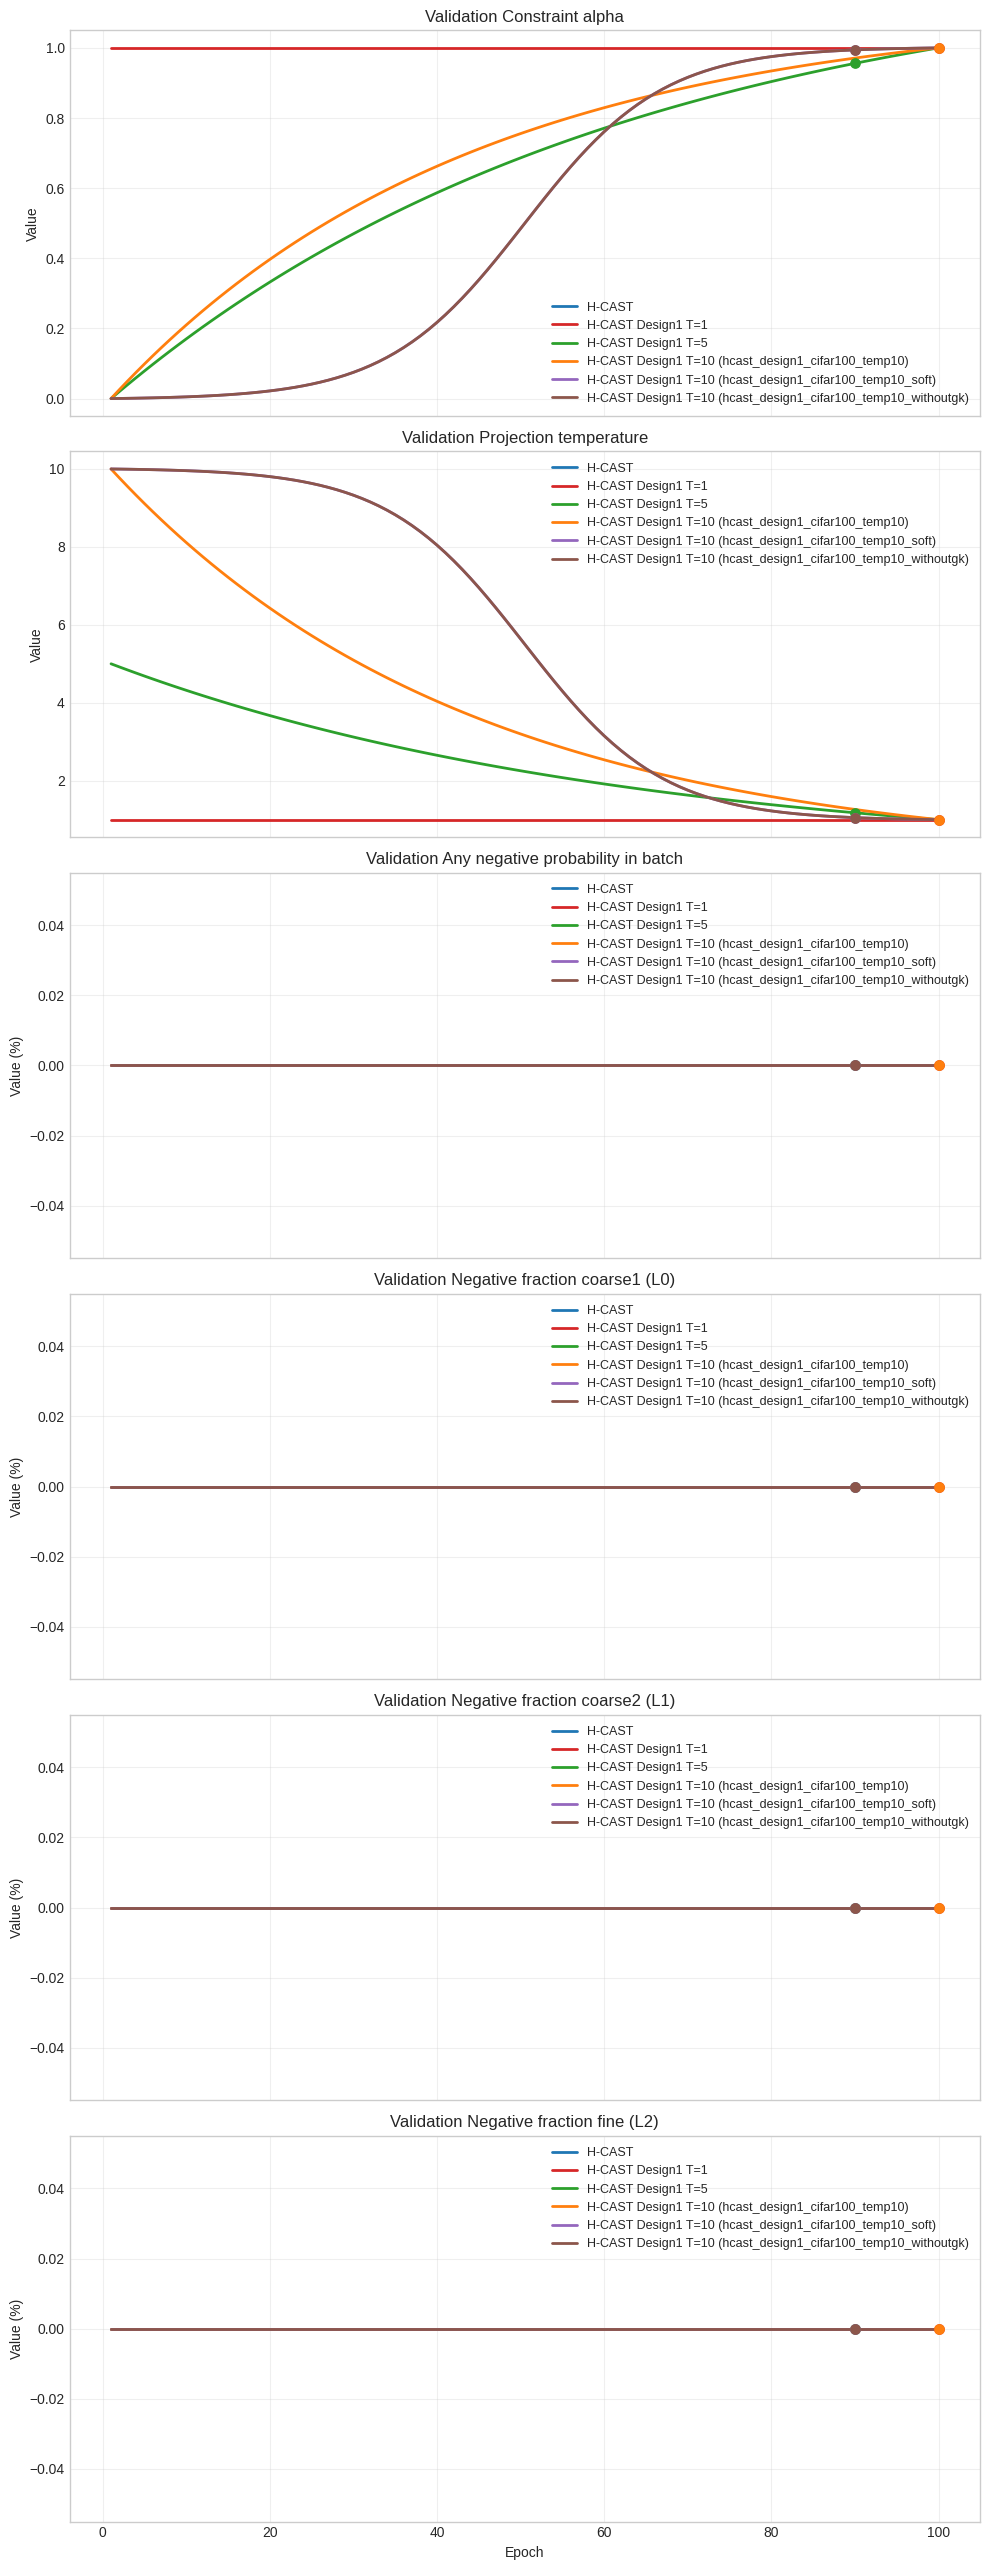

In [5]:
diag_specs = [
    ('proj_constraint_alpha', 'Constraint alpha', False),
    ('proj_constraint_strength', 'Constraint strength', False),
    ('proj_temperature', 'Projection temperature', False),
    ('proj_mode_intrinsic_soft', 'Intrinsic-soft mode flag (1=true)', False),
    ('proj_has_negative', 'Any negative probability in batch', True),
]

neg_frac_level_ids = sorted({
    int(key.rsplit('_', 1)[-1])
    for run_data in run_data_list
    for event in run_data['epoch_events']
    for key in event['val_metrics_norm'].keys()
    if key.startswith('proj_neg_frac_level_') and key.rsplit('_', 1)[-1].isdigit()
})
for level_idx in neg_frac_level_ids:
    level_name = get_level_label(level_idx, run_data_list[0])
    diag_specs.append((
        f'proj_neg_frac_level_{level_idx}',
        f'Negative fraction {level_name} (L{level_idx})',
        True,
    ))

active_diag_specs = []
for metric_key, title, is_percent in diag_specs:
    has_finite = False
    for run_data in run_data_list:
        _, values = get_metric_series(run_data['epoch_events'], metric_key)
        if np.any(np.isfinite(values)):
            has_finite = True
            break
    if has_finite:
        active_diag_specs.append((metric_key, title, is_percent))

if not active_diag_specs:
    print('No projection diagnostics found in current runs.')
else:
    fig, axes = plt.subplots(len(active_diag_specs), 1, figsize=(10, 4.3 * len(active_diag_specs)), sharex=True)
    if len(active_diag_specs) == 1:
        axes = [axes]

    for ax, (metric_key, title, is_percent) in zip(axes, active_diag_specs):
        for run_data in run_data_list:
            epochs, values = get_metric_series(run_data['epoch_events'], metric_key)
            plot_values = values * 100.0 if is_percent else values
            ax.plot(
                epochs,
                plot_values,
                label=run_data['label'],
                color=run_data['color'],
                linewidth=2.0,
            )

            best_event = run_data['best_epoch_event']
            if best_event is not None:
                best_value = float(best_event['val_metrics_norm'].get(metric_key, np.nan))
                if np.isfinite(best_value):
                    best_plot_value = best_value * 100.0 if is_percent else best_value
                    ax.scatter(
                        [best_event['epoch']],
                        [best_plot_value],
                        color=run_data['color'],
                        marker='o',
                        s=45,
                        zorder=4,
                    )

        ax.set_title(f'Validation {title}')
        ax.set_ylabel('Value (%)' if is_percent else 'Value')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    axes[-1].set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()


## Training Loss Comparison

This section compares training losses between runs for both aggregate losses (`total`, `level_ce`, `gk_loss`) and per-level losses (`loss_level_*`).

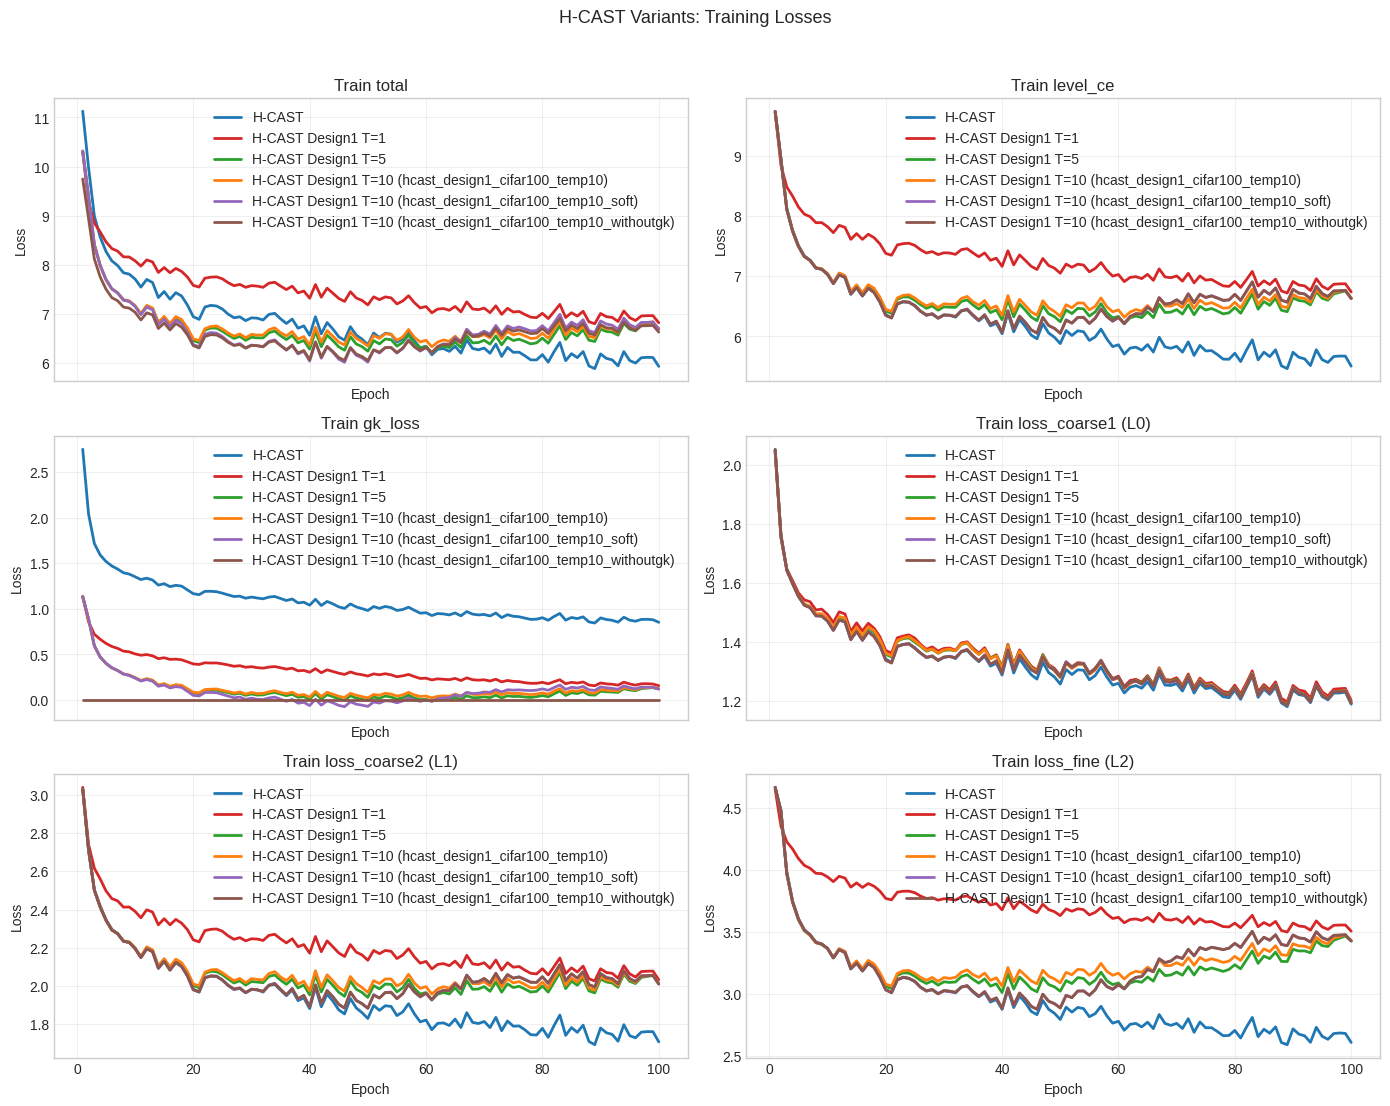

In [6]:
def get_train_loss_series(epoch_events, loss_key):
    epochs = [int(event['epoch']) for event in epoch_events]
    values = [float(event.get('train_losses', {}).get(loss_key, np.nan)) for event in epoch_events]
    return np.array(epochs, dtype=np.int32), np.array(values, dtype=np.float64)

aggregate_loss_keys = ['total', 'level_ce', 'gk_loss']
level_loss_ids = sorted({
    int(key.rsplit('_', 1)[-1])
    for run_data in run_data_list
    for event in run_data['epoch_events']
    for key in event.get('train_losses', {}).keys()
    if key.startswith('loss_level_') and key.rsplit('_', 1)[-1].isdigit()
})

metric_specs = [(key, key) for key in aggregate_loss_keys]
for level_idx in level_loss_ids:
    level_name = get_level_label(level_idx, run_data_list[0])
    metric_specs.append((f'loss_level_{level_idx}', f'loss_{level_name} (L{level_idx})'))

n_metrics = len(metric_specs)
ncols = 2
nrows = int(np.ceil(n_metrics / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.6 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for ax, (metric_key, metric_title) in zip(axes, metric_specs):
    for run_data in run_data_list:
        epochs, values = get_train_loss_series(run_data['epoch_events'], metric_key)
        ax.plot(
            epochs,
            values,
            label=run_data['label'],
            color=run_data['color'],
            linewidth=2.0,
        )
    ax.set_title(f'Train {metric_title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes[n_metrics:]:
    ax.axis('off')

plt.suptitle('H-CAST Variants: Training Losses', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (CIFAR-100)

Interpretation note:
- Each chart corresponds to one selected run on CIFAR-100.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



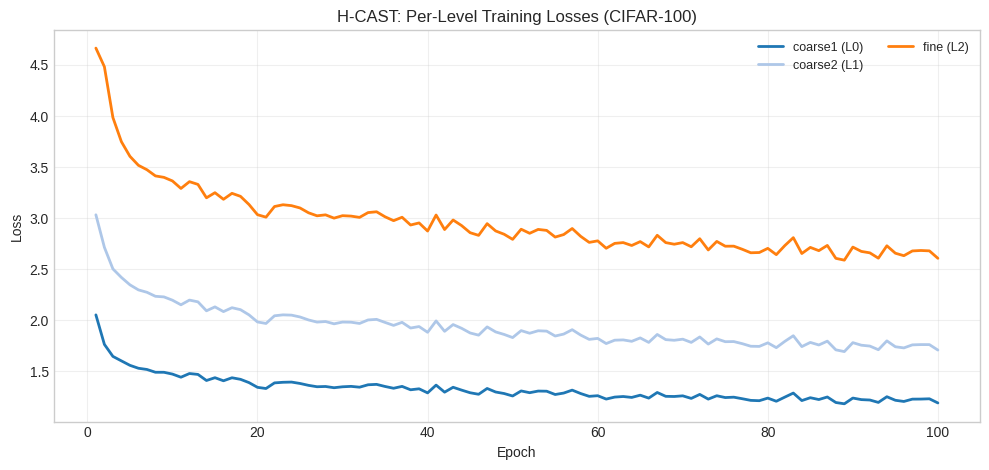

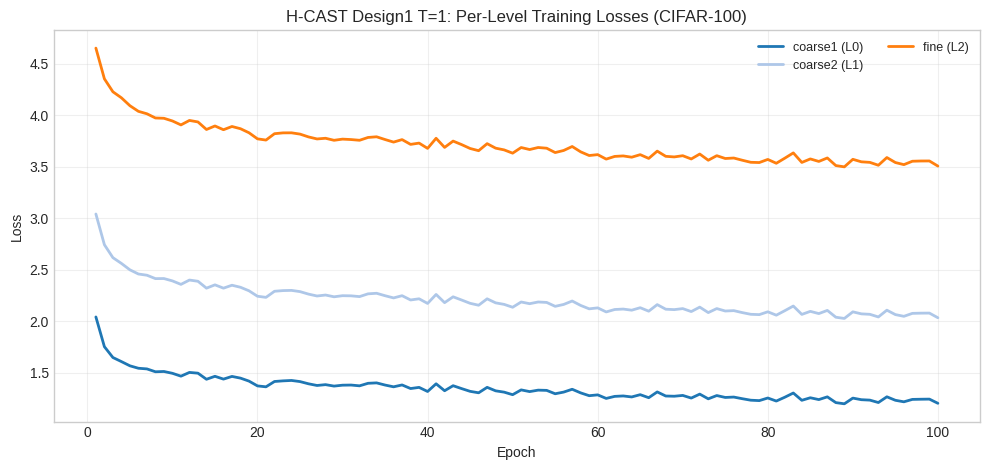

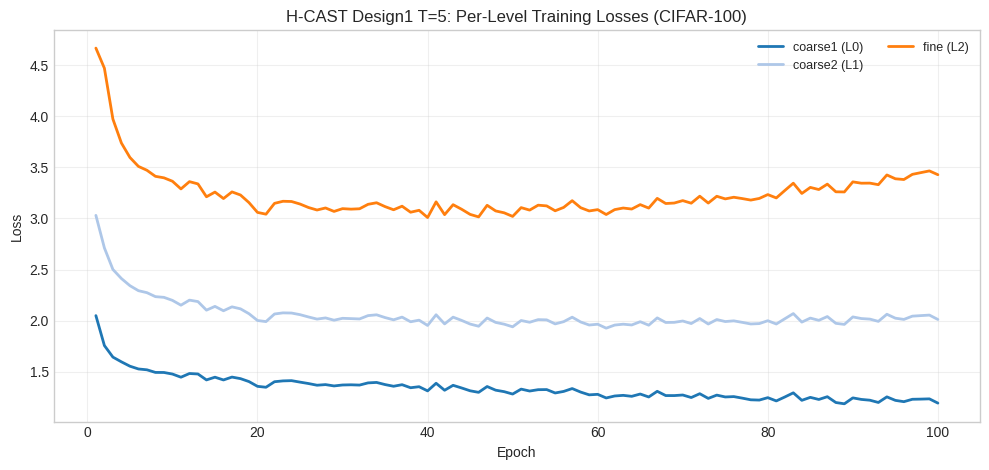

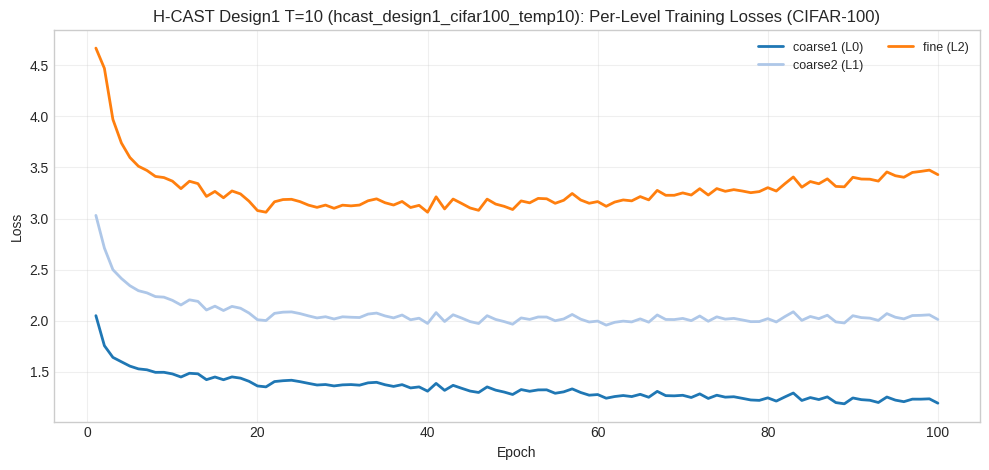

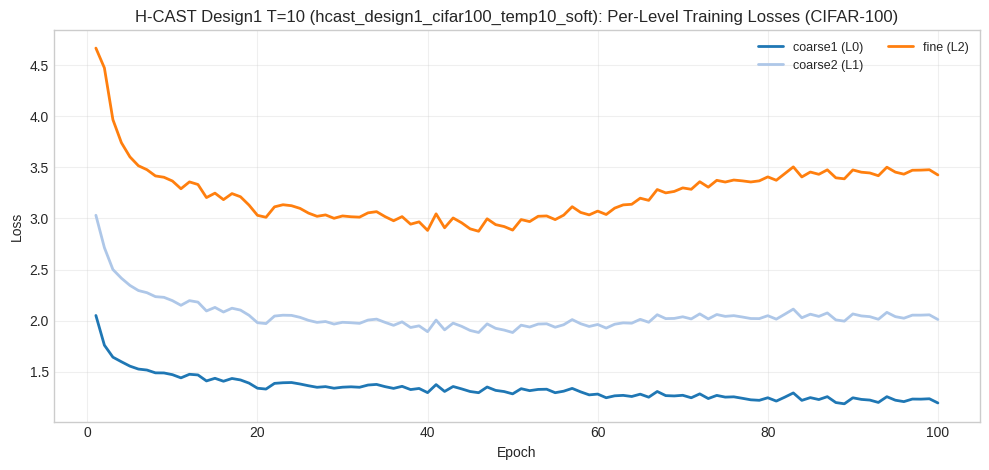

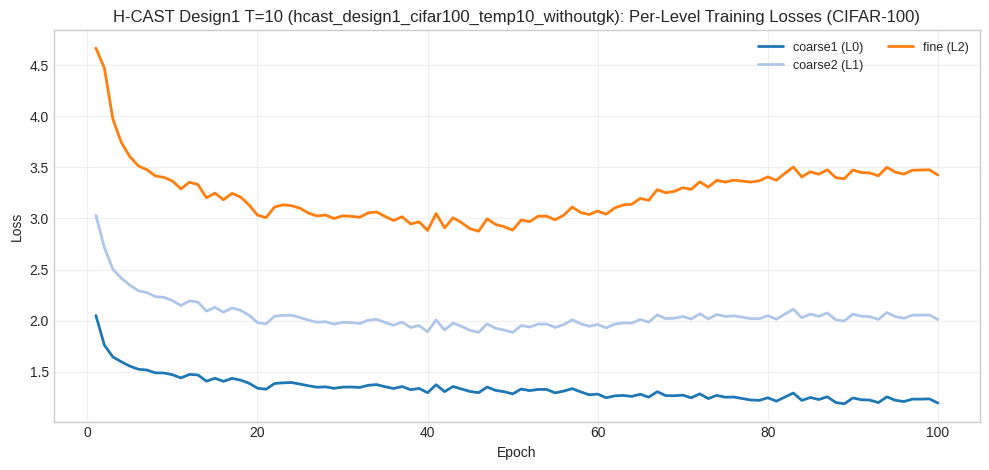

In [7]:
for run_data in run_data_list:
    all_loss_keys = sorted({
        key
        for event in run_data['epoch_events']
        for key in event.get('train_losses', {}).keys()
    })

    level_loss_ids = sorted({
        int(key.rsplit('_', 1)[-1])
        for key in all_loss_keys
        if key.startswith('loss_level_') and key.rsplit('_', 1)[-1].isdigit()
    })

    if not level_loss_ids:
        print(f"No per-level train losses for {run_data['label']}")
        continue

    fig, ax = plt.subplots(figsize=(10, 4.8))
    cmap = plt.get_cmap('tab20')
    plotted = 0

    for idx, level_idx in enumerate(level_loss_ids):
        metric_key = f'loss_level_{level_idx}'
        epochs, values = get_train_loss_series(run_data['epoch_events'], metric_key)
        if np.all(~np.isfinite(values)):
            continue

        level_name = get_level_label(level_idx, run_data)
        ax.plot(
            epochs,
            values,
            label=f'{level_name} (L{level_idx})',
            color=cmap(idx % 20),
            linewidth=2.0,
        )
        plotted += 1

    if plotted == 0:
        plt.close(fig)
        print(f"No finite per-level train losses for {run_data['label']}")
        continue

    ax.set_title(f"{run_data['label']}: Per-Level Training Losses (CIFAR-100)")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()



## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

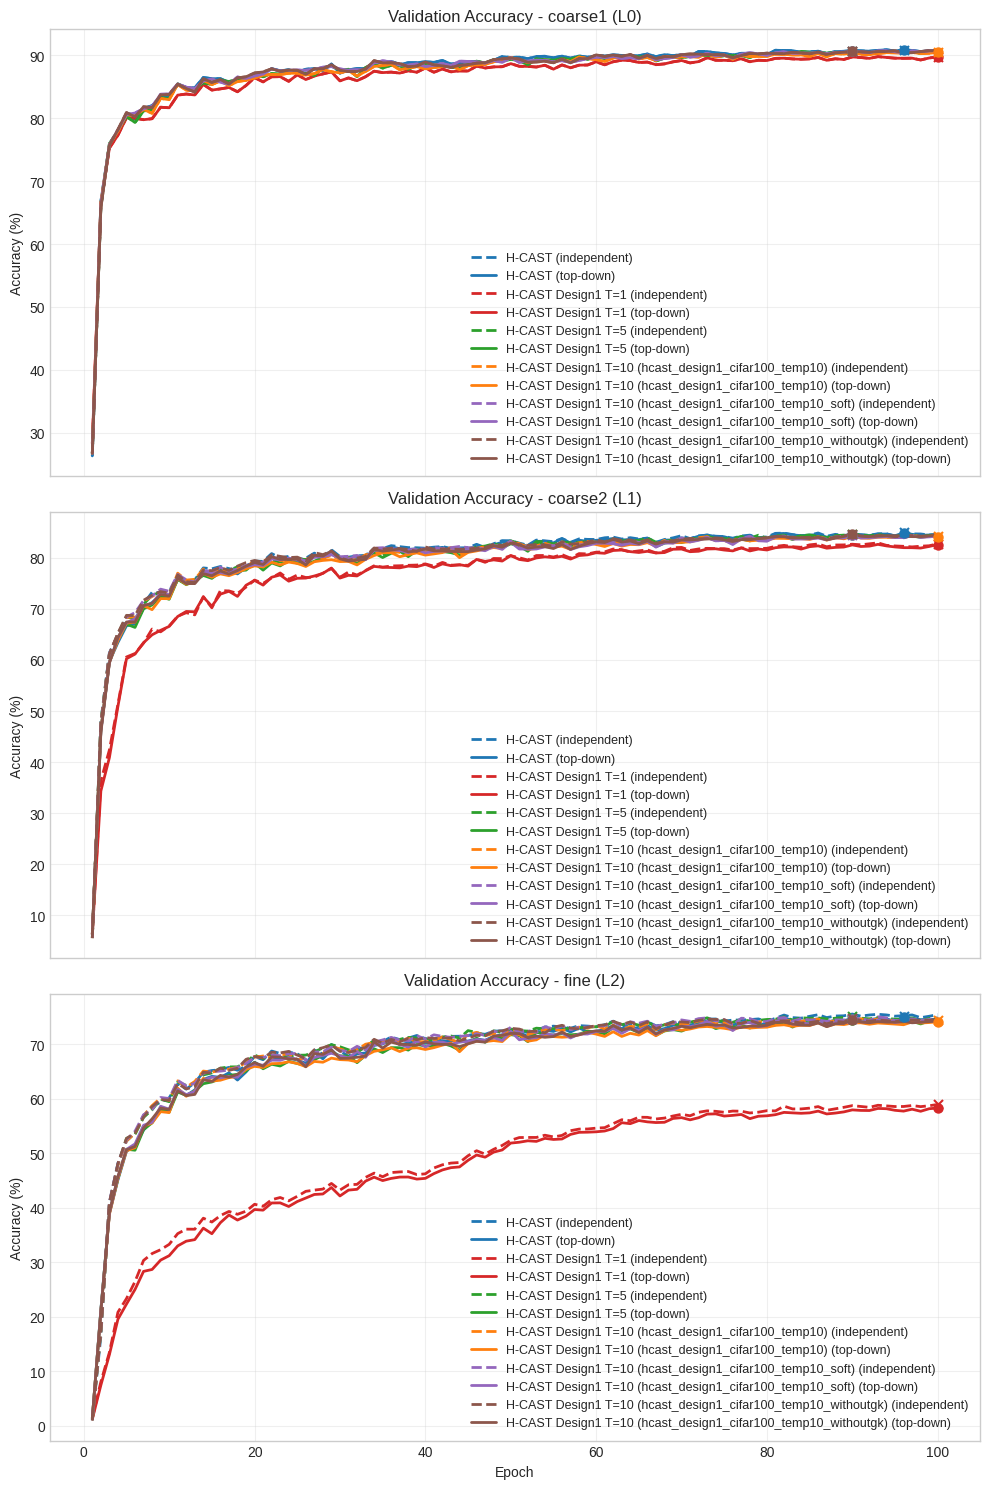

In [8]:
all_level_ids = sorted({
    int(key.rsplit('_', 1)[-1])
    for run_data in run_data_list
    for event in run_data['epoch_events']
    for key in event['val_metrics_norm'].keys()
    if (
        (key.startswith('acc_level_topdown_') or key.startswith('acc_level_independent_'))
        and key.rsplit('_', 1)[-1].isdigit()
    )
})

if not all_level_ids:
    raise ValueError('No per-level validation accuracy metrics found.')

fig, axes = plt.subplots(len(all_level_ids), 1, figsize=(10, 5 * len(all_level_ids)), sharex=True)
if len(all_level_ids) == 1:
    axes = [axes]

mode_specs = [
    ('independent', '--', 'independent', 'x'),
    ('topdown', '-', 'top-down', 'o'),
]

for ax, level_idx in zip(axes, all_level_ids):
    for run_data in run_data_list:
        level_label = get_level_label(level_idx, run_data)
        for mode_key, line_style, mode_label, marker in mode_specs:
            metric_key = f'acc_level_{mode_key}_{level_idx}'
            epochs, values = get_metric_series(run_data['epoch_events'], metric_key)
            ax.plot(
                epochs,
                values * 100.0,
                label=f"{run_data['label']} ({mode_label})",
                color=run_data['color'],
                linestyle=line_style,
                linewidth=2.0,
            )

            best_event = run_data['best_epoch_event']
            if best_event is not None:
                best_value = float(best_event['val_metrics_norm'].get(metric_key, np.nan))
                if np.isfinite(best_value):
                    ax.scatter(
                        [best_event['epoch']],
                        [best_value * 100.0],
                        color=run_data['color'],
                        marker=marker,
                        s=42,
                        zorder=4,
                    )

    ax.set_title(f'Validation Accuracy - {level_label} (L{level_idx})')
    ax.set_ylabel('Accuracy (%)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

The table compares key test metrics for all runs and reports deltas versus the baseline run (`H-CAST`) in percentage points, including both `independent` and `topdown` per-level accuracies.

In [9]:
if len(run_data_list) < 2:
    raise ValueError('This table expects at least two runs (baseline + comparison).')

base = run_data_list[0]
comparisons = run_data_list[1:]

metric_rows = [
    ('fpa_independent', 'FPA independent'),
    ('fpa_topdown', 'FPA top-down'),
    ('weighted_ap_independent', 'wAP independent'),
    ('weighted_ap_topdown', 'wAP top-down'),
    ('tice_independent', 'TICE independent'),
    ('tice_topdown', 'TICE top-down'),
    ('ahd_independent', 'AHD independent'),
    ('ahd_topdown', 'AHD top-down'),
]

for level_idx in all_level_ids:
    level_label = get_level_label(level_idx, base)
    metric_rows.append((f'acc_level_independent_{level_idx}', f'Acc independent {level_label} (L{level_idx})'))
    metric_rows.append((f'acc_level_topdown_{level_idx}', f'Acc top-down {level_label} (L{level_idx})'))


def fmt_pct(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    return f'{100.0 * x:.2f}%'


def fmt_delta_pp(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    sign = '+' if x >= 0 else ''
    return f'{sign}{100.0 * x:.2f} pp'


def fmt_edges(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    return f'{x:.3f}'


def fmt_delta_edges(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    sign = '+' if x >= 0 else ''
    return f'{sign}{x:.3f}'


header = f"{'Metric':<40}{base['label']:>16}"
for comp in comparisons:
    header += f"{comp['label']:>20}{'Delta vs base':>18}"
print(header)
print('-' * len(header))

for metric_key, metric_name in metric_rows:
    base_value = float(base['test_metrics'].get(metric_key, np.nan))
    is_distance_metric = metric_key.startswith('ahd_')
    base_fmt = fmt_edges(base_value) if is_distance_metric else fmt_pct(base_value)
    row = f"{metric_name:<40}{base_fmt:>16}"
    for comp in comparisons:
        comp_value = float(comp['test_metrics'].get(metric_key, np.nan))
        delta_value = comp_value - base_value if np.isfinite(base_value) and np.isfinite(comp_value) else np.nan
        comp_fmt = fmt_edges(comp_value) if is_distance_metric else fmt_pct(comp_value)
        delta_fmt = fmt_delta_edges(delta_value) if is_distance_metric else fmt_delta_pp(delta_value)
        row += f"{comp_fmt:>20}{delta_fmt:>18}"
    print(row)


Metric                                            H-CAST  H-CAST HCC T=1     Delta vs base  H-CAST HCC T=5     Delta vs baseH-CAST HCC T=10 (hcast_hcc_cifar100_temp10)     Delta vs baseH-CAST HCC T=10 (hcast_hcc_cifar100_temp10_soft)     Delta vs baseH-CAST HCC T=10 (hcast_hcc_cifar100_temp10_withoutgk)     Delta vs base
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
FPA independent                                   71.96%              58.37%         -13.59 pp              72.16%          +0.20 pp              72.56%          +0.60 pp              72.84%          +0.88 pp              73.00%          +1.04 pp
FPA top-down                                      73.81%              58.94

Interpretation note:
- Positive delta means the comparison run is higher than baseline for that metric; for `tice_*`, lower is better, so negative delta is desirable.
- Compare temperature variants against baseline to see whether stronger or weaker early constraints help.
- Compare independent vs top-down rows per level to quantify how much hierarchy constraints affect each run.


In [10]:
print('Quick summary')
print('------------')
for run_data in run_data_list:
    best = run_data['best_epoch_event']
    if best is None:
        continue
    best_fpa_ind = best['val_metrics_norm'].get('fpa_independent', np.nan)
    best_fpa_td = best['val_metrics_norm'].get('fpa_topdown', np.nan)
    best_wap_ind = best['val_metrics_norm'].get('weighted_ap_independent', np.nan)
    best_wap_td = best['val_metrics_norm'].get('weighted_ap_topdown', np.nan)
    best_tice_ind = best['val_metrics_norm'].get('tice_independent', np.nan)
    best_tice_td = best['val_metrics_norm'].get('tice_topdown', np.nan)
    best_ahd_ind = best['val_metrics_norm'].get('ahd_independent', np.nan)
    best_ahd_td = best['val_metrics_norm'].get('ahd_topdown', np.nan)
    best_proj_alpha = best['val_metrics_norm'].get('proj_constraint_alpha', np.nan)
    best_proj_strength = best['val_metrics_norm'].get('proj_constraint_strength', np.nan)
    best_proj_temp = best['val_metrics_norm'].get('proj_temperature', np.nan)
    best_proj_mode_soft = best['val_metrics_norm'].get('proj_mode_intrinsic_soft', np.nan)
    proj_summary_parts = []
    if np.isfinite(best_proj_alpha):
        proj_summary_parts.append(f'proj_alpha={best_proj_alpha:.3f}')
    if np.isfinite(best_proj_strength):
        proj_summary_parts.append(f'proj_strength={best_proj_strength:.3f}')
    if np.isfinite(best_proj_temp):
        proj_summary_parts.append(f'proj_temp={best_proj_temp:.3f}')
    if np.isfinite(best_proj_mode_soft):
        proj_summary_parts.append(f'intrinsic_soft={int(best_proj_mode_soft >= 0.5)}')
    proj_summary_txt = '' if not proj_summary_parts else ', ' + ', '.join(proj_summary_parts)

    print(
        f"{run_data['label']}: best epoch={best['epoch']}, "
        f"val FPA_ind={100.0 * best_fpa_ind:.2f}%, val FPA_td={100.0 * best_fpa_td:.2f}%, "
        f"val wAP_ind={100.0 * best_wap_ind:.2f}%, val wAP_td={100.0 * best_wap_td:.2f}%, "
        f"val TICE_ind={100.0 * best_tice_ind:.2f}%, val TICE_td={100.0 * best_tice_td:.2f}%, "
        f"val AHD_ind={best_ahd_ind:.3f}, val AHD_td={best_ahd_td:.3f}{proj_summary_txt}"
    )

for comp in comparisons:
    fpa_ind_delta = comp['test_metrics'].get('fpa_independent', np.nan) - base['test_metrics'].get('fpa_independent', np.nan)
    fpa_td_delta = comp['test_metrics'].get('fpa_topdown', np.nan) - base['test_metrics'].get('fpa_topdown', np.nan)
    wap_ind_delta = comp['test_metrics'].get('weighted_ap_independent', np.nan) - base['test_metrics'].get('weighted_ap_independent', np.nan)
    wap_td_delta = comp['test_metrics'].get('weighted_ap_topdown', np.nan) - base['test_metrics'].get('weighted_ap_topdown', np.nan)
    tice_ind_delta = comp['test_metrics'].get('tice_independent', np.nan) - base['test_metrics'].get('tice_independent', np.nan)
    tice_td_delta = comp['test_metrics'].get('tice_topdown', np.nan) - base['test_metrics'].get('tice_topdown', np.nan)
    ahd_ind_delta = comp['test_metrics'].get('ahd_independent', np.nan) - base['test_metrics'].get('ahd_independent', np.nan)
    ahd_td_delta = comp['test_metrics'].get('ahd_topdown', np.nan) - base['test_metrics'].get('ahd_topdown', np.nan)
    print(
        f"Test delta ({comp['label']} - {base['label']}): "
        f'FPA_ind={100.0 * fpa_ind_delta:+.2f} pp, '
        f'FPA_td={100.0 * fpa_td_delta:+.2f} pp, '
        f'wAP_ind={100.0 * wap_ind_delta:+.2f} pp, '
        f'wAP_td={100.0 * wap_td_delta:+.2f} pp, '
        f'TICE_ind={100.0 * tice_ind_delta:+.2f} pp, '
        f'TICE_td={100.0 * tice_td_delta:+.2f} pp, '
        f'AHD_ind={ahd_ind_delta:+.3f}, '
        f'AHD_td={ahd_td_delta:+.3f}'
    )


Quick summary
------------
H-CAST: best epoch=96, val FPA_ind=72.75%, val FPA_td=74.97%, val wAP_ind=77.76%, val wAP_td=77.52%, val TICE_ind=8.66%, val TICE_td=0.00%, val AHD_ind=1.036, val AHD_td=0.984
H-CAST HCC T=1: best epoch=100, val FPA_ind=57.76%, val FPA_td=58.29%, val wAP_ind=64.59%, val wAP_td=64.06%, val TICE_ind=4.38%, val TICE_td=0.00%, val AHD_ind=1.407, val AHD_td=1.386, proj_alpha=1.000, proj_temp=1.000
H-CAST HCC T=5: best epoch=90, val FPA_ind=73.54%, val FPA_td=74.53%, val wAP_ind=77.63%, val wAP_td=77.10%, val TICE_ind=4.66%, val TICE_td=0.00%, val AHD_ind=1.033, val AHD_td=1.006, proj_alpha=0.956, proj_temp=1.177
H-CAST HCC T=10 (hcast_hcc_cifar100_temp10): best epoch=100, val FPA_ind=73.45%, val FPA_td=74.11%, val wAP_ind=77.03%, val wAP_td=76.70%, val TICE_ind=3.07%, val TICE_td=0.00%, val AHD_ind=1.048, val AHD_td=1.026, proj_alpha=1.000, proj_temp=1.000
H-CAST HCC T=10 (hcast_hcc_cifar100_temp10_soft): best epoch=90, val FPA_ind=73.84%, val FPA_td=74.60%, val w